Loading the unhealthy dataset

In [2]:
import cv2
import os
from PIL import Image
import time
import matplotlib.pyplot as plt
import numpy as np

Loaded 250 images.


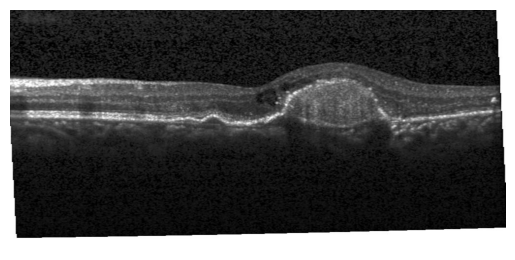

In [3]:

folder_path = "Data/CellData/OCT/test/CNV"

# Get all image file names
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpeg', '.jpeg'))]

# Load them
images_unhealthy = []
for file in image_files:
    img_path = os.path.join(folder_path, file)
    img = Image.open(img_path)
    images_unhealthy.append(img)

print(f"Loaded {len(images_unhealthy)} images.")

plt.imshow(images_unhealthy[5], cmap='gray')
plt.axis('off')

plt.show()


Loading the healthy dataset

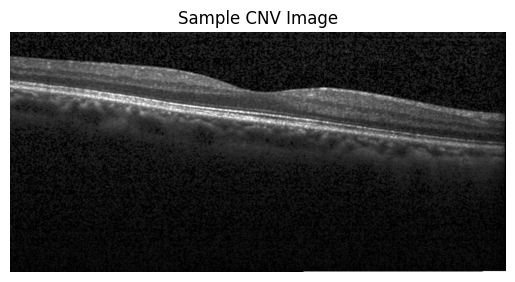

In [4]:

# Path to your folder
folder_path = "Data/CellData/OCT/test/Normal"

# Get all image file names
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpeg', '.jpeg'))]

# Load them
images_healthy = []
for file in image_files:
    img_path = os.path.join(folder_path, file)
    img = Image.open(img_path)
    images_healthy.append(img)

plt.imshow(images_healthy[3], cmap='gray')
plt.axis('off')
plt.title('Sample CNV Image')
plt.show()


Remove borders

Updated 250 unhealthy and 250 healthy images (white borders set to black).


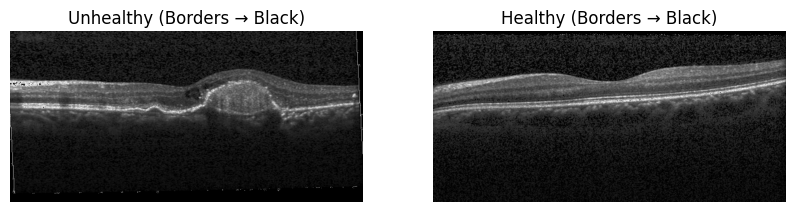

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Function to replace white border pixels with black
def remove_white_borders(img, threshold=250):
    gray = img.convert("L")
    arr = np.array(gray)
    mask = arr >= threshold
    arr[mask] = 0
    return Image.fromarray(arr)

# 🔄 Modify the existing arrays directly
for i in range(len(images_unhealthy)):
    images_unhealthy[i] = remove_white_borders(images_unhealthy[i])

for i in range(len(images_healthy)):
    images_healthy[i] = remove_white_borders(images_healthy[i])

print(f"Updated {len(images_unhealthy)} unhealthy and {len(images_healthy)} healthy images (white borders set to black).")

# Show before and after for one example
idx = 5
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy[idx], cmap='gray')
plt.axis('off')
plt.title('Unhealthy (Borders → Black)')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy[idx], cmap='gray')
plt.axis('off')
plt.title('Healthy (Borders → Black)')

plt.show()


Enhanced 250 unhealthy images and 250 healthy images.


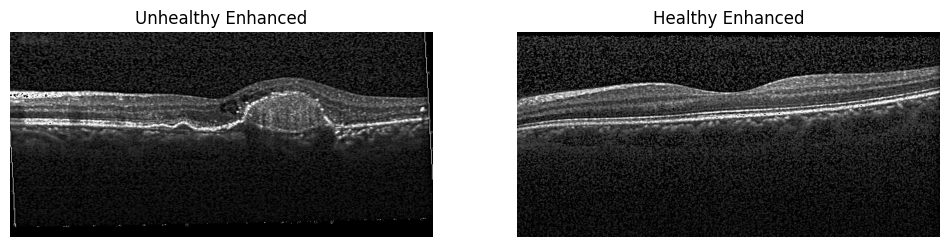

In [6]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def enhance_low_high(img, blur_kernel=(27, 27), highpass_weight=1.0):
    """
    Apply Gaussian low-pass filter + high-pass enhancement.
    Returns a grayscale PIL image.
    """
    # Convert to grayscale and float32
    gray = img.convert("L")
    arr = np.array(gray).astype(np.float32)
    
    # Low-pass (Gaussian blur)
    blurred = cv2.GaussianBlur(arr, blur_kernel, 0)
    
    # High-pass
    highpass = arr - blurred
    
    # Combine (original + weighted high-pass)
    sharpened = cv2.addWeighted(arr, 1.0, highpass, highpass_weight, 0)
    
    # Clip to valid range
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return Image.fromarray(sharpened)

# 🧠 Apply to all images
images_unhealthy_enhanced = [enhance_low_high(img) for img in images_unhealthy]
images_healthy_enhanced = [enhance_low_high(img) for img in images_healthy]

print(f"Enhanced {len(images_unhealthy_enhanced)} unhealthy images and {len(images_healthy_enhanced)} healthy images.")

# 🔍 Show one example from each
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Unhealthy Enhanced')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Healthy Enhanced')

plt.show()


Filter

Computed vertical edges (contrast enhanced) for 250 unhealthy and 250 healthy images.


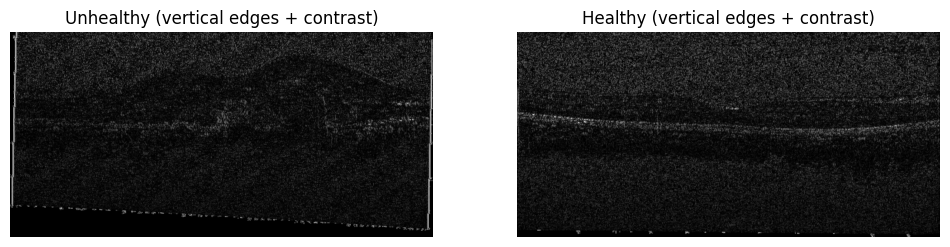

In [7]:


def vertical_edges_sobel(img, ksize=3, enhance_contrast=True):
    """
    Returns a grayscale PIL image of vertical edges using Sobel X.
    Optionally enhances contrast with normalization or CLAHE.
    """
    g = np.array(img.convert("L"))
    gradx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=ksize)  # dx=1, dy=0 → vertical edges
    edge = np.abs(gradx)
    
    # Normalize to 0–255
    edge = (edge / (edge.max() + 1e-8) * 255).astype(np.uint8)
    
    if enhance_contrast:
        # CLAHE (adaptive histogram equalization) works great for edge maps
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        edge = clahe.apply(edge)
    
    return Image.fromarray(edge)

# Apply to both datasets (creates edge maps with stronger contrast)
images_unhealthy_vert = [vertical_edges_sobel(im, ksize=3) for im in images_unhealthy]
images_healthy_vert   = [vertical_edges_sobel(im, ksize=3) for im in images_healthy]

print(f"Computed vertical edges (contrast enhanced) for {len(images_unhealthy_vert)} unhealthy and {len(images_healthy_vert)} healthy images.")

# Preview
idx = 4
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(images_unhealthy_vert[idx], cmap='gray'); plt.axis('off'); plt.title('Unhealthy (vertical edges + contrast)')
plt.subplot(1,2,2); plt.imshow(images_healthy_vert[idx], cmap='gray'); plt.axis('off'); plt.title('Healthy (vertical edges + contrast)')
plt.show()


Computed horizontal edges for 250 unhealthy and 250 healthy images.


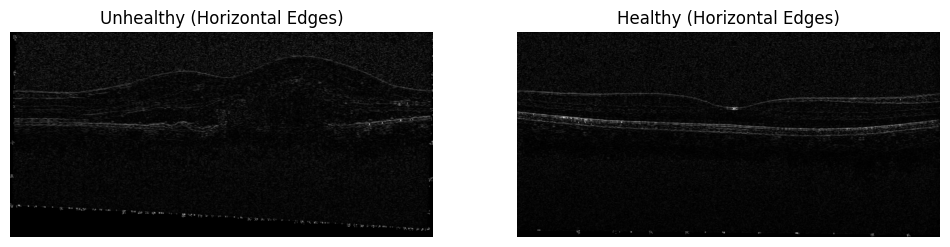

In [8]:


def horizontal_edges_sobel(img, ksize=3):
    """
    Returns a grayscale PIL image of horizontal edges using Sobel Y.
    ksize must be 1, 3, 5, or 7.
    """
    g = np.array(img.convert("L"))
    grady = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=ksize)  # dx=0, dy=1 → horizontal edges
    edge = np.abs(grady)
    edge = (edge / (edge.max() + 1e-8) * 255).astype(np.uint8)
    return Image.fromarray(edge)

# 🧠 Apply to both datasets
images_unhealthy_horz = [horizontal_edges_sobel(im, ksize=3) for im in images_unhealthy]
images_healthy_horz   = [horizontal_edges_sobel(im, ksize=3) for im in images_healthy]

print(f"Computed horizontal edges for {len(images_unhealthy_horz)} unhealthy and {len(images_healthy_horz)} healthy images.")

# 🔍 Show example
idx = 4
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_horz[idx], cmap='gray')
plt.axis('off')
plt.title('Unhealthy (Horizontal Edges)')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_horz[idx], cmap='gray')
plt.axis('off')
plt.title('Healthy (Horizontal Edges)')

plt.show()


Only keep bright pixels

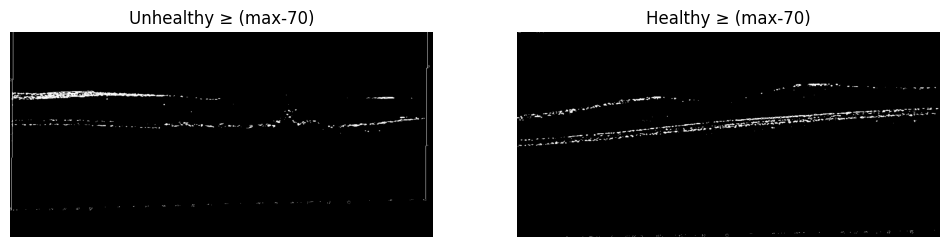

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

def keep_top_band(pil_list, delta=20):
    """
    For each PIL 'L' image:
      - find max intensity
      - threshold at max - delta
      - keep original values where >= threshold, else 0
    Returns list of uint8 numpy arrays.
    """
    out = []
    for im in pil_list:
        # ensure grayscale ndarray
        if isinstance(im, PIL.Image.Image):
            g = np.array(im.convert("L"), dtype=np.uint8)
        else:
            g = np.array(im, dtype=np.uint8)
        maxv = int(g.max())
        thr = max(0, maxv - int(delta))
        keep = (g >= thr)
        result = np.where(keep, g, 0).astype(np.uint8)
        out.append(result)
    return out

# Apply to your variables (no files saved)
unhealthy_top = keep_top_band(images_unhealthy_enhanced, delta=70)
healthy_top   = keep_top_band(images_healthy_enhanced,   delta=70)

# Quick visual check on the 5th item (index 4). Change to 5 for the 6th, etc.
idx = 6
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(unhealthy_top[idx], cmap='gray'); plt.axis('off'); plt.title('Unhealthy ≥ (max-70)')
plt.subplot(1,2,2); plt.imshow(healthy_top[idx],   cmap='gray'); plt.axis('off');  plt.title('Healthy ≥ (max-70)')
plt.show()


Line detection

In [ ]:
import numpy as np, cv2, matplotlib.pyplot as plt
import PIL.Image

def to_gray_uint8(img):
    if isinstance(img, PIL.Image.Image):
        return np.array(img.convert("L"), dtype=np.uint8)
    arr = np.array(img)
    if arr.ndim == 3:
        return cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY).astype(np.uint8)
    return arr.astype(np.uint8)

def moving_average_1d(x, k=13):
    k = max(3, int(k)|1)
    pad = k//2
    xp = np.pad(x.astype(np.float32), (pad,pad), mode='edge')
    ker = np.ones(k, np.float32)/k
    return np.convolve(xp, ker, mode='valid')

def trace_primary_line_envelope(
    thr_img,
    band_frac=0.28,      # ROI height (fraction of H) – wider helps bumps
    up_bias=0.55,        # mild bias where ROI centers (0=top, 1=bottom)
    max_up=22,           # allow large upward climbs
    max_down=3,          # strongly limit downward jumps
    smooth_win=13,       # light smoothing
    min_width_ratio=0.25 # require enough horizontal support to define ROI
):
    """
    thr_img: thresholded uint8 image (bright pixels kept, rest 0).
    Returns (y_curve, overlay_bgr).
    """
    g = to_gray_uint8(thr_img)
    H, W = g.shape

    # Binary mask + gentle connect to bridge tiny gaps
    mask = (g > 0).astype(np.uint8) * 255
    mask = cv2.medianBlur(mask, 3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(11,1)), iterations=2)
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT,(1,5)), iterations=1)

    # If there are too few bright pixels, return flat line
    if mask.sum() < H*W*0.005:
        y_flat = np.full(W, H//2, dtype=np.int32)
        return y_flat, cv2.cvtColor(g, cv2.COLOR_GRAY2BGR)

    # --- auto ROI around band with most bright support ---
    row_support = (mask>0).sum(axis=1).astype(np.float32)
    row_support /= (row_support.max() + 1e-6)
    bias = 1.0 - np.abs(np.linspace(0,1,H) - up_bias)
    score = 0.8*row_support + 0.2*bias
    cy = int(np.argmax(score))
    half = int(max(8, H*band_frac/2))
    y0, y1 = max(0, cy-half), min(H, cy+half)
    # if support extremely low, widen once
    if row_support[cy] < W*min_width_ratio*0.1:
        y0, y1 = max(0, cy-2*half), min(H, cy+2*half)

    # --- greedy envelope tracker with asymmetric move cost ---
    y_curve = np.full(W, np.nan, dtype=np.float32)
    # seed at left: choose brightest within ROI
    ys0 = np.flatnonzero(mask[y0:y1, 0]) + y0
    if ys0.size:
        y_prev = int(ys0[np.argmax(g[ys0, 0])])
    else:
        y_prev = int(np.clip(cy, y0, y1-1))
    y_curve[0] = y_prev

    for x in range(1, W):
        ys = np.flatnonzero(mask[y0:y1, x]) + y0
        if ys.size == 0:
            # no candidate – keep previous (will be smoothed/interpolated later)
            y_curve[x] = y_prev
            continue

        # brightness term
        b = g[ys, x].astype(np.float32) / 255.0

        # distance penalties (asymmetric)
        dy = ys - y_prev
        penalty = np.zeros_like(b)
        penalty[dy > 0] = -np.minimum(dy[dy > 0], max_down) * 0.6      # going down: penalize quickly
        penalty[dy < 0] = -np.minimum(-dy[dy < 0], max_up) * 0.05      # going up: small penalty

        # final score: brightness dominates, then mild distance + penalty
        score = 0.9*b + 0.1*(-np.abs(dy)/max_up) + penalty
        y = int(ys[np.argmax(score)])

        # clamp asymmetric moves
        if y - y_prev > max_down:
            y = y_prev + max_down
        if y_prev - y > max_up:
            y = y_prev - max_up

        y_curve[x] = y
        y_prev = y

    # --- smooth without flattening the dome ---
    y_curve = moving_average_1d(y_curve, k=smooth_win).astype(np.int32)

    # overlay
    overlay = cv2.cvtColor(g, cv2.COLOR_GRAY2BGR)
    pts = np.stack([np.arange(W), y_curve], axis=1).reshape(-1,1,2)
    cv2.polylines(overlay, [pts], False, (0,255,255), 2, lineType=cv2.LINE_AA)

    return y_curve, overlay

# ===== run on your thresholded lists =====
# unhealthy_top, healthy_top produced by your keep_top_band(...)

idx = 8  # 5th image
uy, u_overlay = trace_primary_line_envelope(unhealthy_top[idx],
                                            band_frac=0.30, up_bias=0.1,
                                            max_up=24, max_down=2, smooth_win=60)
hy, h_overlay = trace_primary_line_envelope(healthy_top[idx],
                                            band_frac=0.30, up_bias=0.1,
                                            max_up=24, max_down=2, smooth_win=60)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(u_overlay, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Unhealthy (5th) — envelope tracer')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(h_overlay, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Healthy (5th) — envelope tracer')
plt.show()


Reverse colors to deteckt black pockets -> add them to the detect lines thingy